In [1]:
import pandas as pd
import numpy as np
from urllib.request import urlopen
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

 1. https://www.moviechart.co.kr/rank/realtime/index/image 를 파싱하여 
 아래처럼 출력하시요

 ```
 데이터프레임 결과임

 영화명    예매율    개봉일        등급       장르       감독  
 ===============================================================    
 모비우스     39.5    2022.03.30  15세이상 액션/어드벤처/공포/SF
 .....
 ```

In [ ]:
base_url = 'https://www.moviechart.co.kr'

def get_html(url):
    response = urlopen(url)
    return BeautifulSoup(response, 'html.parser')

html = get_html(base_url + '/rank/realtime/index/image')
today = pd.Timestamp.today().normalize()

mydata = []
for li in html.select('.movieBox-list > li.movieBox-item'):
    a = li.select_one('.movie-title h3 > a')
    mydata.append({'순위': int(li.select_one('.rank').string),
                   '영화명': a.string.strip(),
                   '예매율': float(li.select_one('.ticketing > span').string.replace('%', '')),
                   '개봉일': li.select_one('.movie-launch').get_text().replace('개봉일 :', '').strip(),
                   'href': a['href']})
len(mydata)

20

In [ ]:
genre, grade, director = [], [], []
for d in mydata:
    detail = get_html(base_url + d['href'])
    info = {}
    for dl in detail.select('.movieInerInfo-list dl'):
        info[dl.select_one('dd').get_text(strip=True)] = dl.select_one('dt').get_text(' ', strip=True)
    parts = [p.strip() for p in info['장르'].split('/')]
    genre.append(parts[0].replace(',', '/'))
    grade.append(parts[-1])
    director.append(info.get('감독', ''))

df = pd.DataFrame(mydata).drop(columns='href')
df['등급'] = grade
df['장르'] = genre
df['감독'] = director
df['개봉일'] = pd.to_datetime(df['개봉일'], format='%Y.%m.%d')
df.set_index('순위', inplace=True)
df

,영화명,예매율,개봉일,등급,장르,감독
순위,,,,,,
1,극장판 치이카와: 인어 섬의 비밀,39.0,2026-09-30,전체관람가,애니메이션,오이카와 케이
2,암살자(들),13.8,2026-09-23,12세이상관람가,범죄/드라마,허진호
3,오디세이,10.5,2026-08-05,15세이상관람가,액션/드라마/어드벤처,크리스토퍼 놀란
4,타짜: 벨제붑의 노래,9.5,2026-09-23,청소년관람불가,범죄/드라마,최국희
5,부활남: 더 레드,7.8,2026-09-30,15세이상관람가,액션,백종열
6,가능한 사랑,3.8,2026-09-23,청소년관람불가,드라마,이창동
7,디거,2.6,2026-10-03,15세이상관람가,코미디/드라마,알레한드로 곤잘레스 이냐리투
8,인턴,2.3,2026-09-16,12세이상관람가,드라마,김도영
9,어벤져스: 엔드게임 앙코르,1.9,2026-09-23,12세이상관람가,액션/SF,조 루소


In [ ]:
import unicodedata

def disp_w(s):
    return sum(2 if unicodedata.east_asian_width(ch) in 'WF' else 1 for ch in str(s))

def pad(s, w, right=False):
    gap = ' ' * (w - disp_w(s))
    return gap + str(s) if right else str(s) + gap

out = df.reset_index(drop=True)
out['개봉일'] = out['개봉일'].dt.strftime('%Y.%m.%d')
out['예매율'] = out['예매율'].map('{:.1f}'.format)

cols = list(out.columns)
widths = {c: max(disp_w(c), *(disp_w(v) for v in out[c])) for c in cols}
right = {'예매율'}
GAP = '   '

def fmt(vals):
    return GAP.join(pad(v, widths[c], c in right) for c, v in zip(cols, vals)).rstrip()

header = fmt(cols)
print('데이터프레임 결과임\n')
print(header)
print('=' * disp_w(header))
for row in out.itertuples(index=False):
    print(fmt(row))

데이터프레임 결과임

영화명                               예매율   개봉일       등급             장르                   감독
극장판 치이카와: 인어 섬의 비밀        39.0   2026.09.30   전체관람가       애니메이션             오이카와 케이
암살자(들)                             13.8   2026.09.23   12세이상관람가   범죄/드라마            허진호
오디세이                               10.5   2026.08.05   15세이상관람가   액션/드라마/어드벤처   크리스토퍼 놀란
타짜: 벨제붑의 노래                     9.5   2026.09.23   청소년관람불가   범죄/드라마            최국희
부활남: 더 레드                         7.8   2026.09.30   15세이상관람가   액션                   백종열
가능한 사랑                             3.8   2026.09.23   청소년관람불가   드라마                 이창동
디거                                    2.6   2026.10.03   15세이상관람가   코미디/드라마          알레한드로 곤잘레스 이냐리투
인턴                                    2.3   2026.09.16   12세이상관람가   드라마                 김도영
어벤져스: 엔드게임 앙코르               1.9   2026.09.23   12세이상관람가   액션/SF                조 루소
옵세션                                  1.1   2026.09.02   청소년관람불가   공포(호러)             커리 바커
극장판 래브라도:

2. 위의 결과를 데이터프레임으로 변환후 예매율이 10.0 이상인 
영화명 예매율 개봉일을 출력하시요

In [5]:
df[df['예매율'] >= 10.0][['영화명', '예매율', '개봉일']]

,영화명,예매율,개봉일
순위,,,
1,극장판 치이카와: 인어 섬의 비밀,39.0,2026-09-30
2,암살자(들),13.8,2026-09-23
3,오디세이,10.5,2026-08-05


3. x축을 영화명 으로 y축을 예매율로 바차트를 그리시요

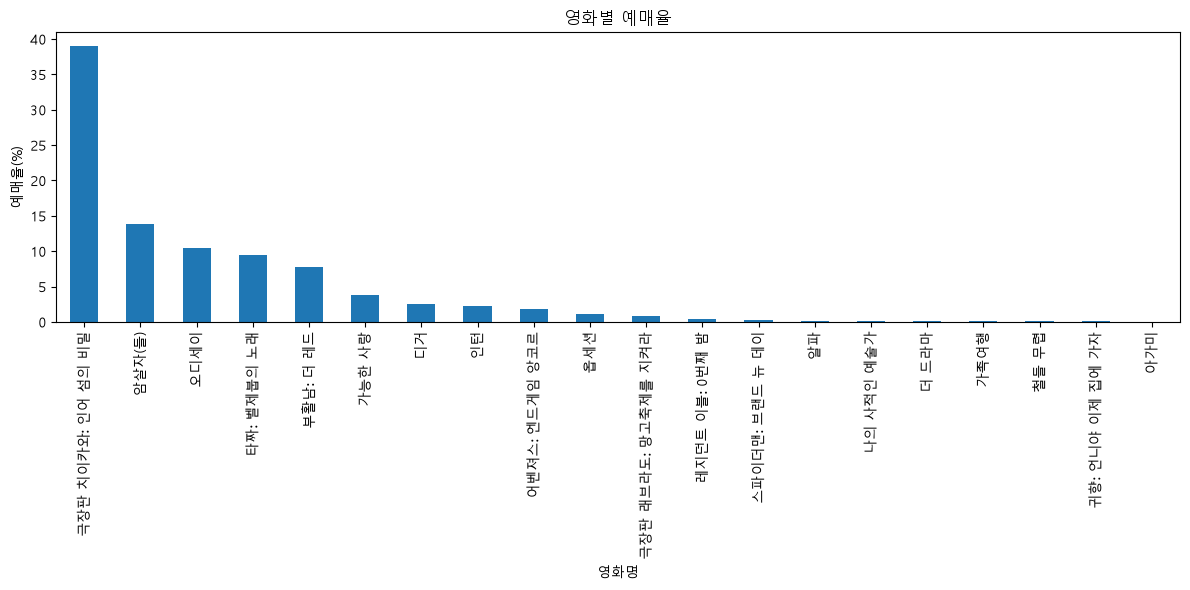

In [6]:
df.plot(kind='bar', x='영화명', y='예매율', rot=90, figsize=(12, 6), legend=False)
plt.xlabel('영화명')
plt.ylabel('예매율(%)')
plt.title('영화별 예매율')
plt.tight_layout()
plt.show()

4. 2026년 09월 25일 이후 개봉한 영화명,예매율,개봉일을 구하시요

In [7]:
df[df['개봉일'] > '2026-09-25'][['영화명', '예매율', '개봉일']]

,영화명,예매율,개봉일
순위,,,
1,극장판 치이카와: 인어 섬의 비밀,39.0,2026-09-30
5,부활남: 더 레드,7.8,2026-09-30
7,디거,2.6,2026-10-03
11,극장판 래브라도: 망고축제를 지켜라,0.9,2026-10-03
14,알파,0.2,2026-09-30


5.  예매율 10.0 이상과 나머지의 비율을 파이차트로 그리시요

63.3 31.4


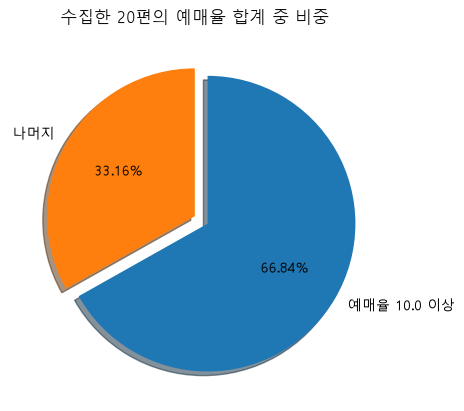

In [8]:
high = df.loc[df['예매율'] >= 10.0, '예매율'].sum()
rest = df.loc[df['예매율'] < 10.0, '예매율'].sum()
print(round(high, 1), round(rest, 1))

plt.pie([high, rest], labels=['예매율 10.0 이상', '나머지'], autopct='%.2f%%',
        shadow=True, explode=[0.1, 0], startangle=90, counterclock=False)
plt.title('수집한 20편의 예매율 합계 중 비중')
plt.show()

6. 예매율 top5를 구하시요

In [9]:
df.nlargest(5, '예매율')[['영화명', '예매율']]

,영화명,예매율
순위,,
1,극장판 치이카와: 인어 섬의 비밀,39.0
2,암살자(들),13.8
3,오디세이,10.5
4,타짜: 벨제붑의 노래,9.5
5,부활남: 더 레드,7.8


7. 장르가 드라마 데이터를 출력하시요

In [10]:
df[df['장르'].str.contains('드라마', na=False)]

,영화명,예매율,개봉일,등급,장르,감독
순위,,,,,,
2,암살자(들),13.8,2026-09-23,12세이상관람가,범죄/드라마,허진호
3,오디세이,10.5,2026-08-05,15세이상관람가,액션/드라마/어드벤처,크리스토퍼 놀란
4,타짜: 벨제붑의 노래,9.5,2026-09-23,청소년관람불가,범죄/드라마,최국희
6,가능한 사랑,3.8,2026-09-23,청소년관람불가,드라마,이창동
7,디거,2.6,2026-10-03,15세이상관람가,코미디/드라마,알레한드로 곤잘레스 이냐리투
8,인턴,2.3,2026-09-16,12세이상관람가,드라마,김도영
14,알파,0.2,2026-09-30,15세이상관람가,드라마,쥘리아 뒤쿠르노
15,나의 사적인 예술가,0.2,2026-09-23,15세이상관람가,드라마,켄트 존스
16,더 드라마,0.1,2026-09-09,15세이상관람가,드라마/멜로,크리스토퍼 보글리


8. 등급별 비율을 파이차트로 그리시요

등급
15세이상관람가    9
12세이상관람가    5
청소년관람불가     4
전체관람가       2
Name: count, dtype: int64


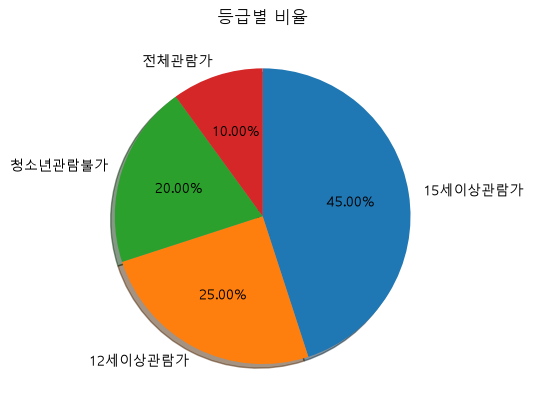

In [11]:
cnt = df['등급'].value_counts()
print(cnt)

plt.pie(cnt, labels=cnt.index, autopct='%.2f%%', shadow=True,
        startangle=90, counterclock=False)
plt.title('등급별 비율')
plt.show()